<a href="https://colab.research.google.com/github/mim-1999/california-housing-regression/blob/main/notebooks/01_eda_and_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing(as_frame=True)

# Convert to dataframe
df = housing.frame

In [5]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
df.shape

(20640, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [13]:
median_income = df['MedInc'].values

In [18]:
median_income_sorted = np.sort(median_income)

In [20]:
min_income = median_income_sorted.min()
max_income = median_income_sorted.max()
print(f"Minimum income is: {min_income:.4f}")
print(f"Maximum income is: {max_income:.4f}")

Minimum income is: 0.4999
Maximum income is: 15.0001


In [23]:
n = len(median_income)
Q1_index = int(0.25 * n)
Q3_index = int(0.75 * n)
Q1 = median_income_sorted[Q1_index]
Q3 = median_income_sorted[Q3_index]
print(f"Q1 is: {Q1:.4f}")
print(f"Q3 is: {Q3:.4f}")

Q1 is: 2.5637
Q3 is: 4.7437


In [25]:
median_position1 = int(0.5 * n)
median_position2 = int(0.5 * (n + 1))
median = (median_income_sorted[median_position1] + median_income_sorted[median_position2]) / 2
print(f"Median is:{median:.4f}")
print(f"Mean income is: {median_income_sorted.mean()}")

Median is:3.5349
Mean income is: 3.8706710029069766


In [28]:
IQR=Q3-Q1
print(f"IQR is: {IQR:.4f}")
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower bound is: {lower_bound:.4f}\nUpper bound is: {upper_bound:4f}")

IQR is: 2.1800
Lower bound is: -0.7063
Upper bound is: 8.013700


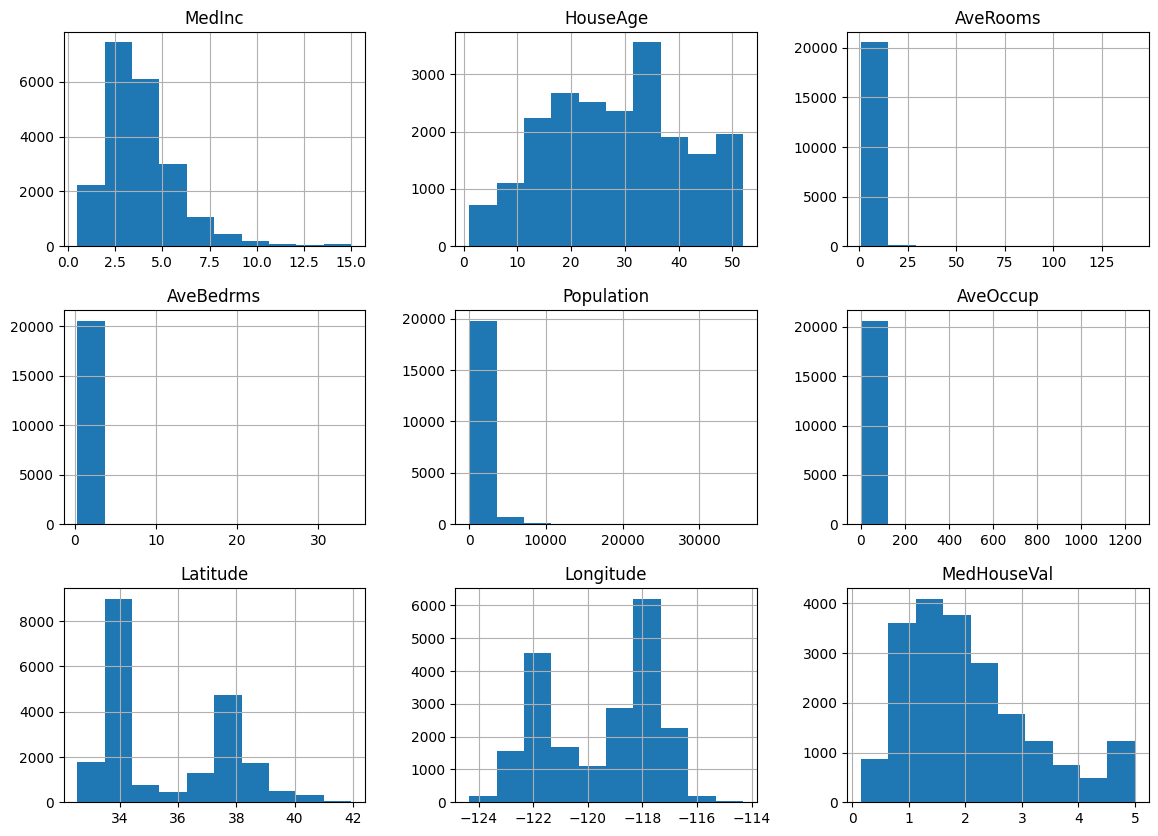

In [29]:
df.hist(figsize=(14,10))
plt.show()